In [1]:
import os
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "functions").exists():
    for parent in REPO_ROOT.parents:
        if (parent / "functions").exists() and (parent / "data").exists():
            REPO_ROOT = parent
            break
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.window_processing import prepare_frechet_data, select_features
from functions.regression import multivariate_frechet_regression
from functions.plot_helper import plot_correlation_trends, plot_multivar_distributions

Using R installation at: C:\Program Files\R\R-4.4.1


# 2-hours window
rmssd and std_consecutive became very equivalent (almost no difference), so can focus on a single thing

In [2]:
features_aireadi = pd.read_csv('data/aireadi_window120.csv')
feature_names = [
                  'Mean', 
                  'CV', 
                  'MAD',
                  #'tir70-180'
                 ]

# Processing for frechet regression with selected features
aireadi_processed = prepare_frechet_data(features_aireadi, feature_names=feature_names)

Processed 968 patients with sufficient data
Average windows per patient: 458.74
Calculating latent correlations... Done!


In [3]:
features_aireadi.head()

,start_time,end_time,Mean,CV,MAD,n_points,slope,tbr<70,tir70-180,tar>180,id
0,2023-07-27 23:51:43,2023-07-28 01:46:43,112.666667,0.090576,4.739130,24,-0.218957,0.0,1.0,0.0,1001
1,2023-07-28 00:21:43,2023-07-28 02:16:43,105.083333,0.126752,5.869565,24,-0.325217,0.0,1.0,0.0,1001
2,2023-07-28 00:51:43,2023-07-28 02:46:43,100.958333,0.116866,6.260870,24,-0.186348,0.0,1.0,0.0,1001
3,2023-07-28 01:21:43,2023-07-28 03:16:43,96.041667,0.097835,7.173913,24,0.006000,0.0,1.0,0.0,1001
4,2023-07-28 01:51:43,2023-07-28 03:46:43,108.708333,0.232405,7.913043,24,0.576957,0.0,1.0,0.0,1001


In [4]:
import os

# Load metadata
metadata = pd.read_csv(os.path.join("data", 'ai_readi_metadata_cleaned.csv'))

# Join metadata with the processed one
joined_df = aireadi_processed['data'].merge(metadata, on='id', how='left')
joined_df.head()

,id,multivar_distribution,n_windows,latentcor,age,study_group,LDL-C,HDL-C,Total-C,TG,HbA1c,log(HbA1c),log(TG)
0,1001,"[[112.66666666666669, 0.0905755592594179, 4.73...",472,"[[1.0, 0.23192958931458585, 0.3392847237905632...",69,pre_diabetes_lifestyle_controlled,94.341690,92.0,201.0,83.0,5.7,1.740466,4.418841
1,1002,"[[102.5, 0.0891940692806665, 3.782608695652174...",468,"[[1.0, 0.45836112144439234, 0.6139068030012014...",69,healthy,133.485054,41.0,202.0,153.0,5.6,1.722767,5.030438
2,1003,"[[180.125, 0.0586292245809029, 3.0869565217391...",469,"[[1.0, 0.22791258651196236, 0.5344146776716303...",82,oral_medication_and_or_non_insulin_injectable_...,105.112772,63.0,192.0,137.0,7.8,2.054124,4.919981
3,1004,"[[145.08333333333334, 0.0516912373767754, 1.91...",472,"[[1.0, 0.23589607691155923, 0.5081916098345747...",61,oral_medication_and_or_non_insulin_injectable_...,59.674544,54.0,128.0,70.0,7.2,1.974081,4.248495
4,1005,"[[144.66666666666666, 0.0507435842063254, 1.26...",446,"[[1.0, -0.21700060000735752, 0.274194443349397...",58,insulin_dependent,74.956702,52.0,141.0,70.0,9.5,2.251292,4.248495


In [5]:
joined_df['n_windows'].describe()

count    968.000000
mean     458.742769
std       31.851370
min      236.000000
25%      464.000000
50%      472.000000
75%      472.000000
max      508.000000
Name: n_windows, dtype: float64

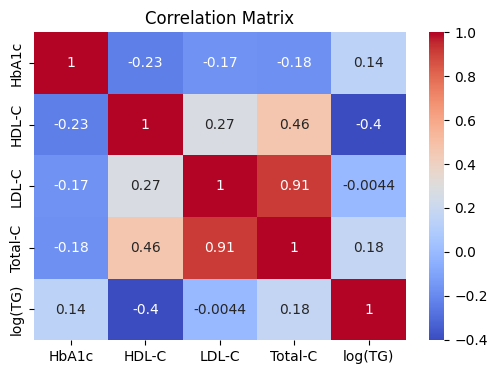

In [6]:
# correlation heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(joined_df[['HbA1c', 'HDL-C', 'Total-C', 'log(TG)']].corr(method='pearson'), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

#### Regression with HbA1c

In [7]:
# bottleneck due to R2 computation; 51 sec
predictor_name = 'HbA1c'
result = multivariate_frechet_regression(predictor_name, joined_df, r_squared=False, space_interval=5, min_q=0.05, max_q=0.995,
                                         feature_names=aireadi_processed['feature_names'],
                                         bounds={'Mean': (40., 400), 'CV': (0., None), 'MAD': (0., None)},
                                         )

Performing Frechet regression using HbA1c as predictor...
    Computing Frechet regression of marginals...    Completed.
    Computing regression of latent correlations ...    Completed.


C:\Users\Junyoung\AppData\Local\Temp\ipykernel_59448\2387163144.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.93, 1])
C:\Users\Junyoung\AppData\Local\Temp\ipykernel_59448\2387163144.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


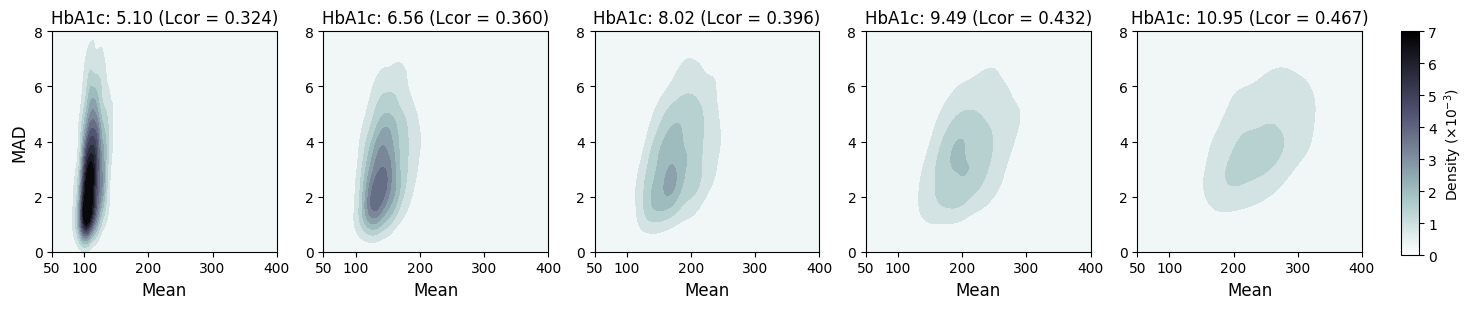

In [8]:
fig = plot_multivar_distributions(result['fits'], axes_names=['Mean', 'MAD'], figsize=(15, 3.2),
                            all_features=result['feature_names'], heatmap=False, vmax=7.,
                            x_range=(50, 400),
                            y_range=(0, 8),  # Set y-axis range directly in the function
                            show=False,
                            )

# Add 50 to x-axis ticks without changing axis limits
axes = fig.get_axes()
for ax in axes[:-1]: # Exclude colorbar axis
    # Get current ticks within the visible range
    current_ticks = [t for t in ax.get_xticks() if 50 <= t <= 400]
    # Add 50 if not already present
    if 50 not in current_ticks:
        current_ticks = [50] + current_ticks
        current_ticks.sort()
    ax.set_xticks(current_ticks)
    ax.set_xlim(50, 400)  # Restore the x-axis limits

# Adjust colorbar position vertically
cbar_ax = axes[-1]  # Last axis is the colorbar
pos = cbar_ax.get_position()
cbar_ax.set_position([pos.x0, pos.y0 + 0.034, pos.width, pos.height])  # Move up by 0.034

fig.tight_layout(rect=[0, 0, 0.93, 1])
plt.savefig('results/real/figs/ai_readi_hba1c_multivar_mad.pdf', format='pdf', dpi=500, bbox_inches='tight')
fig.show()

C:\Users\Junyoung\AppData\Local\Temp\ipykernel_27292\151214500.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.93, 1])
C:\Users\Junyoung\AppData\Local\Temp\ipykernel_27292\151214500.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


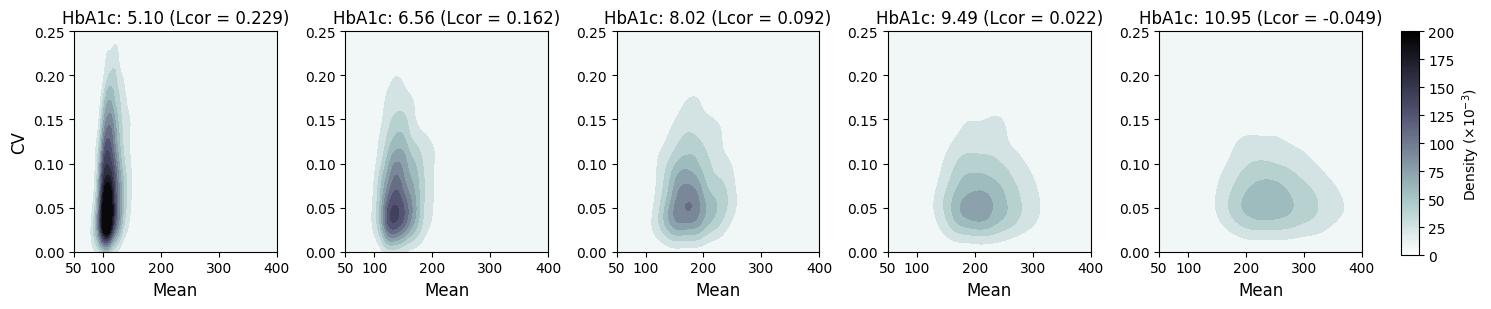

In [ ]:
# CV distribution not that differs
fig = plot_multivar_distributions(result['fits'], axes_names=['Mean', 'CV'], figsize=(15, 3.2),
                            all_features=result['feature_names'], heatmap=False, vmax=200.,
                            x_range=(50, 400),
                            y_range=(0, 0.25),  # Set y-axis range directly in the function
                            show=False,
                            )

# Add 50 to x-axis ticks without changing axis limits
axes = fig.get_axes()
for ax in axes[:-1]: # Exclude colorbar axis
    # Get current ticks within the visible range
    current_ticks = [t for t in ax.get_xticks() if 50 <= t <= 400]
    # Add 50 if not already present
    if 50 not in current_ticks:
        current_ticks = [50] + current_ticks
        current_ticks.sort()
    ax.set_xticks(current_ticks)
    ax.set_xlim(50, 400)  # Restore the x-axis limits

# Adjust colorbar position vertically
cbar_ax = axes[-1]  # Last axis is the colorbar
pos = cbar_ax.get_position()
cbar_ax.set_position([pos.x0, pos.y0 + 0.033, pos.width, pos.height])  # Move up by 0.033

fig.tight_layout(rect=[0, 0, 0.93, 1])
fig.show()

In [9]:
# New function to plot correlation fits with real data scatter
def plot_correlation_fits(result, predictor_name, joined_df, feature_names, figsize=(15, 4), show=True):
    """
    Plot fitted latent correlations as thick lines and real data as scatter points.
    
    Parameters:
    ----------
    result : dict
        The output of multivariate_frechet_regression
    predictor_name : str
        Name of the predictor variable
    joined_df : pd.DataFrame
        DataFrame containing the raw data with 'latentcor' column
    feature_names : list
        List of feature names (e.g., ['Mean', 'CV', 'MAD'])
    figsize : tuple
        Figure size
    """
    # Extract fitted latent correlations
    fitted_cors = np.array(result['fits']['latentcor_fits'].to_list())
    predictor_vals = result['fits'][predictor_name].values
    
    # Get feature indices
    all_features = result['feature_names']
    feature_indices = [all_features.index(name) for name in feature_names]
    
    # Extract fitted correlations for specified features
    fitted_cors = fitted_cors[:, feature_indices, :][:, :, feature_indices]
    
    # Extract real data correlations
    real_cors = np.array(joined_df['latentcor'].to_list())
    real_cors = real_cors[:, feature_indices, :][:, :, feature_indices]
    real_predictor = joined_df[predictor_name].values
    
    # Create pairs
    pairs = [(0, 1), (0, 2), (1, 2)]  # Mean vs CV, Mean vs MAD, CV vs MAD
    pair_names = [f'{feature_names[i]} vs {feature_names[j]}' for i, j in pairs]
    
    # Collect all correlation values to determine y-axis limits
    all_real_cors = []
    all_fitted_cors = []
    for i, j in pairs:
        all_real_cors.extend([real_cors[k, i, j] for k in range(len(real_predictor))])
        all_fitted_cors.extend([fitted_cors[k, i, j] for k in range(len(predictor_vals))])
    
    # Calculate overall min and max for y-axis
    y_min = min(min(all_real_cors), min(all_fitted_cors))
    y_max = max(max(all_real_cors), max(all_fitted_cors))
    y_margin = (y_max - y_min) * 0.05  # Add 5% margin
    
    # Create figure with 3 panels
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    for ax_idx, (pair, pair_name) in enumerate(zip(pairs, pair_names)):
        i, j = pair
        
        # Real data scatter
        real_cors_pair = [real_cors[k, i, j] for k in range(len(real_predictor))]
        axes[ax_idx].scatter(real_predictor, real_cors_pair, alpha=0.3, s=20, color='gray', label='Observed')
        
        # Fitted line (thick)
        fitted_cors_pair = [fitted_cors[k, i, j] for k in range(len(predictor_vals))]
        axes[ax_idx].plot(predictor_vals, fitted_cors_pair, linewidth=3, color='red', label='Fitted')
        
        # Add horizontal line at correlation = 0
        axes[ax_idx].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.3)
        
        # Labels and title
        axes[ax_idx].set_xlabel(predictor_name, fontsize=11)
        if ax_idx == 0: axes[ax_idx].set_ylabel('Latent Correlation', fontsize=11)
        axes[ax_idx].set_title(pair_name, fontsize=12)
        axes[ax_idx].legend(fontsize=9)
        axes[ax_idx].set_ylim(y_min - y_margin, y_max + y_margin)
    
    if show:
        plt.tight_layout()
        plt.show()
    return fig

In [10]:
predictor_name = 'HbA1c'
result = multivariate_frechet_regression(predictor_name, joined_df, r_squared=False, space_interval=20, #min_q=0.01, max_q=0.998,
                                         feature_names=aireadi_processed['feature_names'],
                                         bounds={'Mean': (40., 400), 'CV': (0., None), 'MAD': (0., None)})

Performing Fréchet regression using HbA1c as predictor...
    Computing Fréchet regression of marginals...    Completed.
    Computing regression of latent correlations ...    Completed.


C:\Users\Junyoung\AppData\Local\Temp\ipykernel_99272\845570207.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


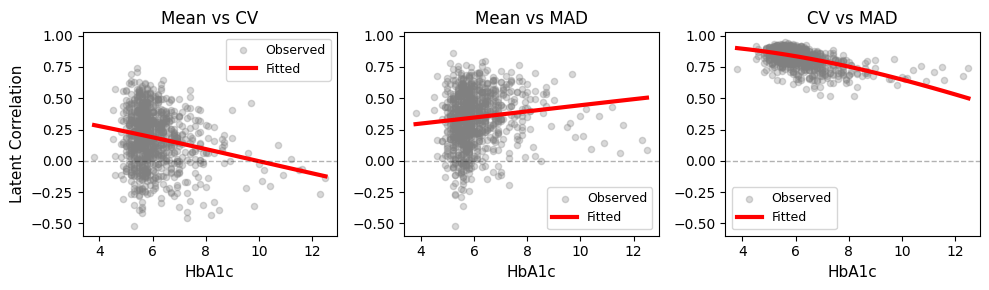

In [11]:
fig = plot_correlation_fits(result, predictor_name, joined_df, feature_names, figsize=(10, 3),
                             show=False
                             )
plt.savefig('results/real/figs/ai_readi_hba1c_latentcor.pdf', format='pdf', dpi=500, bbox_inches='tight')
fig.tight_layout()
fig.show()

g:\My Drive\Experiments\Multivar-Wasserstein\functions\plot_helper.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.93, 1])
g:\My Drive\Experiments\Multivar-Wasserstein\functions\plot_helper.py:98: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


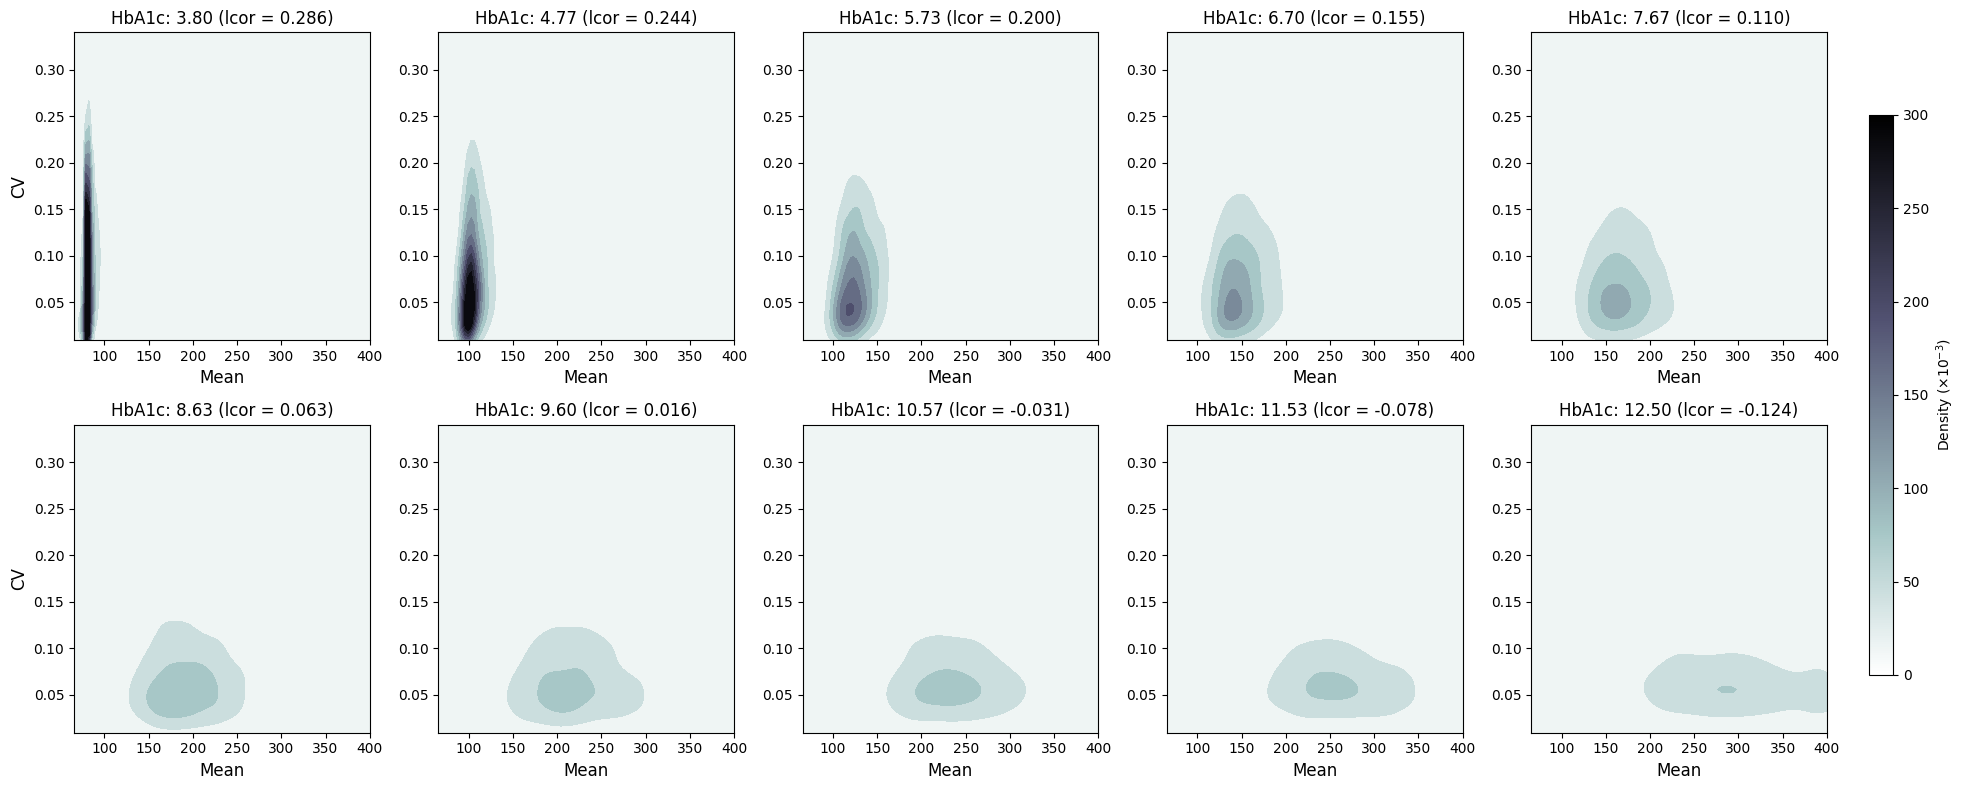

In [9]:
plot_multivar_distributions(result['fits'], axes_names=['Mean', 'CV'],
                            all_features=result['feature_names'], heatmap=False, vmax=300,
                            )

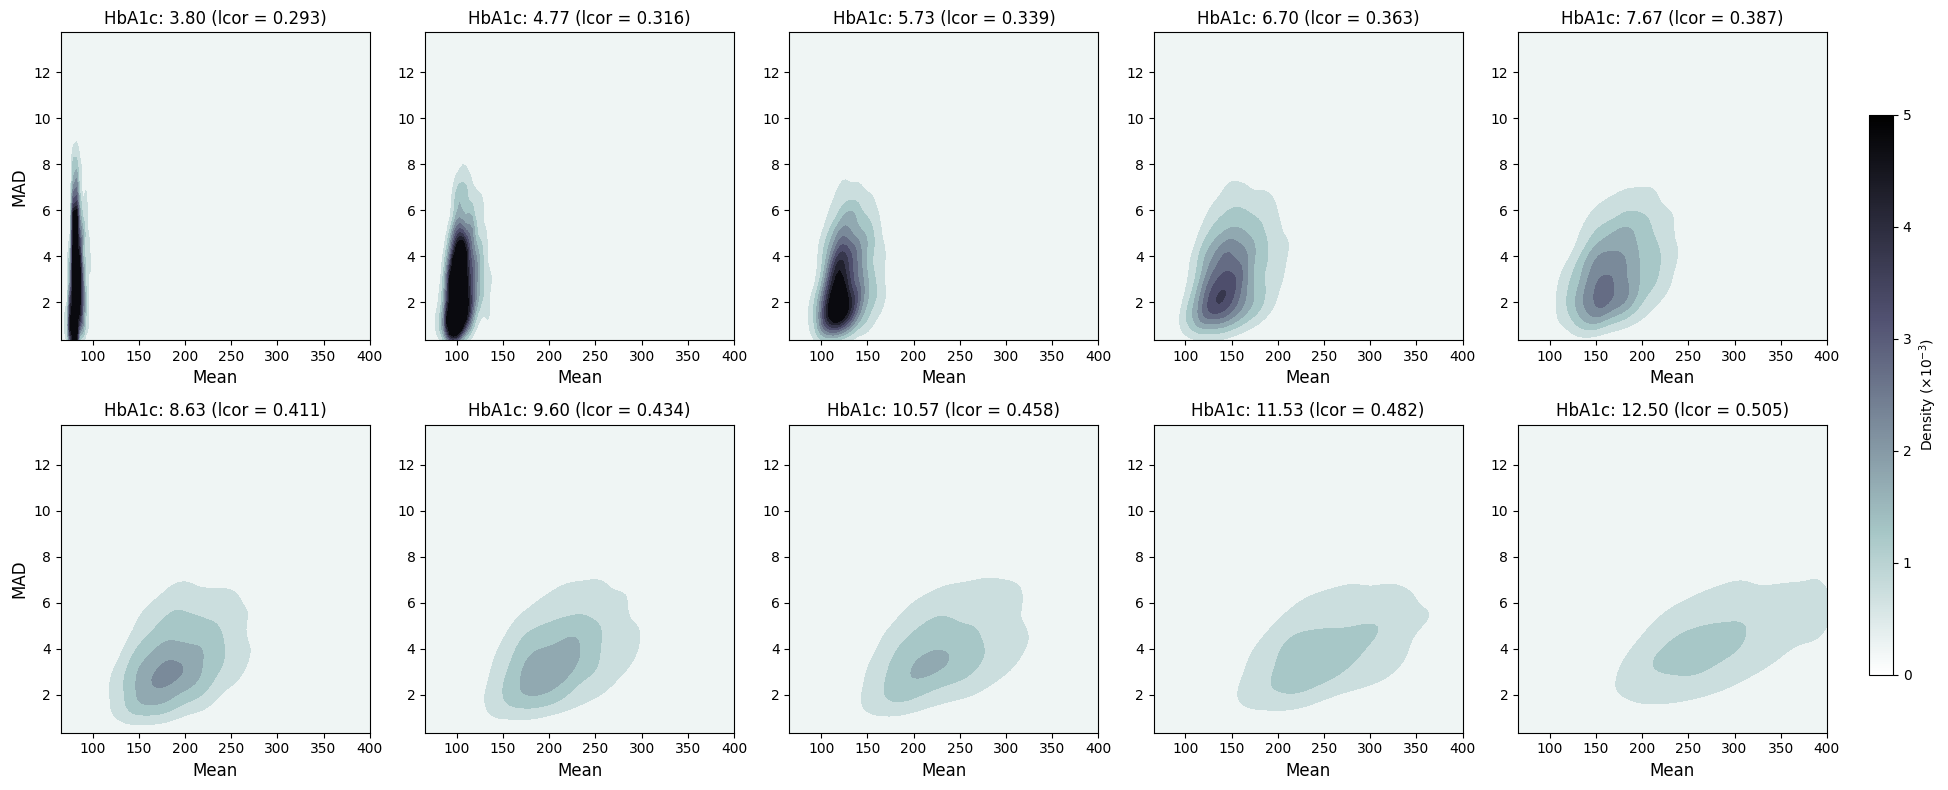

In [10]:
plot_multivar_distributions(result['fits'], axes_names=['Mean', 'MAD'],
                            all_features=result['feature_names'], heatmap=False, vmax=5,
                            )

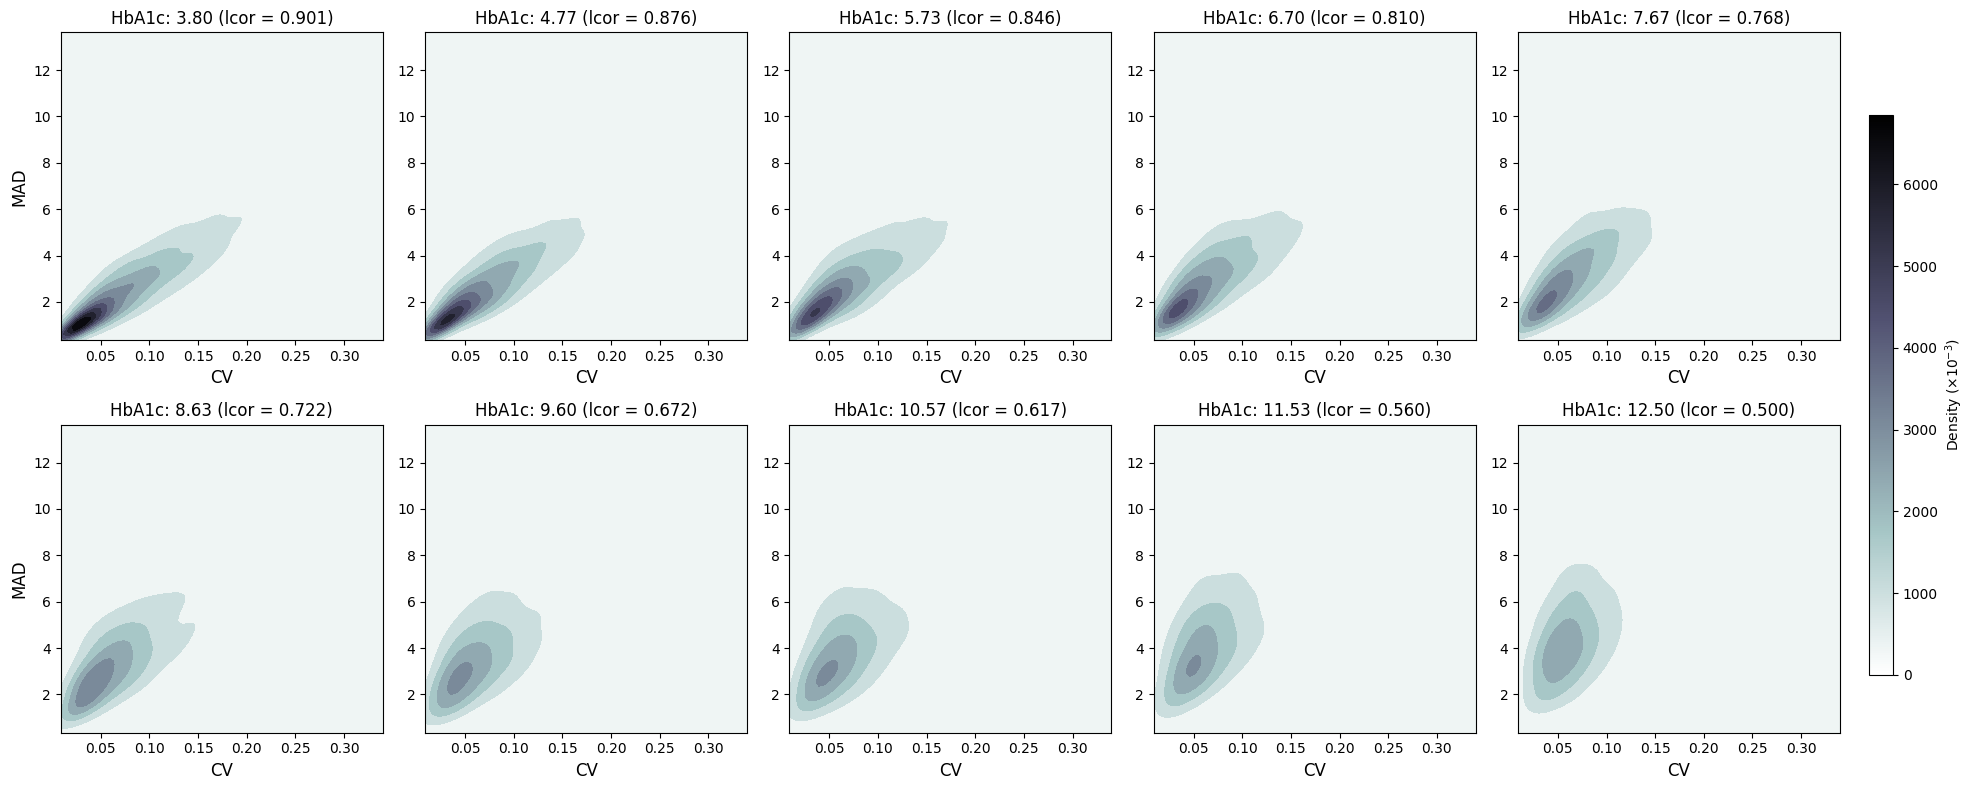

In [11]:
plot_multivar_distributions(result['fits'], axes_names=['CV', 'MAD'],
                            all_features=result['feature_names'], heatmap=False, #vmax=600,
                            )

##### Plot of some random subjects

In [39]:
hba1c_values = [6.5, 7.5, 8.5, 9.5, 11.2]

# select one row for each hba1c value
selected_rows = []
for val in hba1c_values:
    row = joined_df.iloc[(joined_df['HbA1c'] - val).abs().argsort()[:1]]
    selected_rows.append(row)
selected_df = pd.concat(selected_rows).reset_index(drop=True)
selected_df

,id,multivar_distribution,n_windows,latentcor,age,study_group,bmi,LDL-C,HDL-C,Total-C,TG,HbA1c,log(TG)
0,1215,"[[145.79166666666666, 0.2174903360784277, 7.23...",472,"[[1.0, 0.12309999488435258, 0.4577728581015015...",79,oral_medication_and_or_non_insulin_injectable_...,27.359398,70.073967,38.0,141.0,197.0,6.5,5.283204
1,4279,"[[139.5, 0.0958404441370676, 3.81644040845712]...",472,"[[1.0, 0.16909806459962246, 0.4318483594955876...",65,oral_medication_and_or_non_insulin_injectable_...,33.211255,37.673090,42.0,91.0,41.0,7.5,3.713572
2,7120,"[[155.5, 0.0730877904447259, 5.583360371987309...",466,"[[1.0, -0.39983630896170747, -0.02340335472580...",42,oral_medication_and_or_non_insulin_injectable_...,26.895403,114.591618,49.0,178.0,77.0,8.5,4.343805
3,1005,"[[144.66666666666666, 0.0507435842063254, 2.17...",472,"[[1.0, -0.25308795158802494, 0.215226113673721...",58,insulin_dependent,26.596278,74.956702,52.0,141.0,70.0,9.5,4.248495
4,1027,"[[296.0416666666667, 0.0281178572971842, 5.698...",472,"[[1.0, -0.8490213746747, -0.7974158429677249],...",53,oral_medication_and_or_non_insulin_injectable_...,31.886252,82.912114,26.0,239.0,797.0,11.2,6.680855


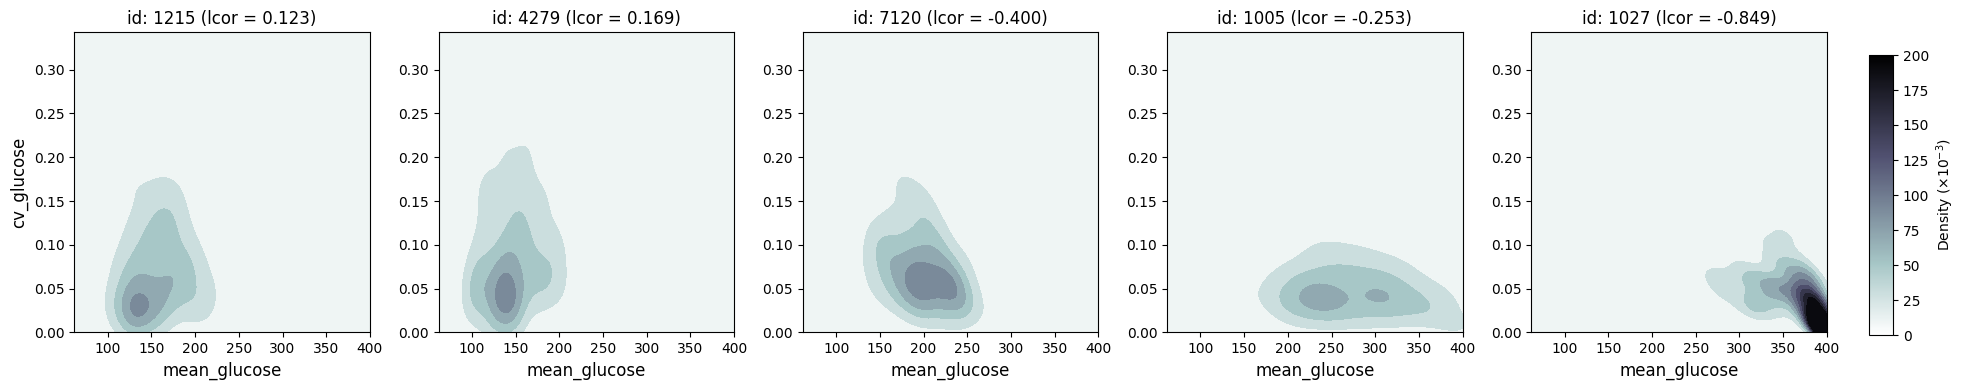

In [ ]:
# Select random five distributions for visualization
# np.random.seed(2025)
idx = np.random.choice(aireadi_processed['data'].shape[0], 5, replace=False)
plot_data = aireadi_processed['data'].iloc[idx]

plot_multivar_distributions(selected_df, axes_names=['Mean', 'cv_glucose'],
                            all_features=aireadi_processed['feature_names'], heatmap=False, vmax=200)

## Two predictors (auxiliary)
Fix the others to medians and plot deciles

In [30]:
predictor_name = ['HbA1c', 'HDL-C']

# Plain R^2 check (2min)
result = multivariate_frechet_regression(predictor_name, joined_df, r_squared=True,
                                         feature_names=aireadi_processed['feature_names'],
                                         bounds={'Mean': (40., 400), 'CV': (0., None), 'MAD': (0., None)})
print(result['R_squares'])

print("Adjusted R-squares:")
n = joined_df.shape[0]
k = len(predictor_name)
adjusted_r2 = 1 - (1 - result['R_squares']) * (n - 1) / (n - k - 1)
print(adjusted_r2)

Performing Fréchet regression using ['HbA1c', 'HDL-C'] as predictor...
    Computing Fréchet regression of marginals...    Completed.
    Computing regression of latent correlations ...    Completed.
    Computing R-squared values for marginal fits... Done
    Computing R-squared value for latent correlation fit... Done!
        Mean        CV      MAD  latentcor     total
R2  0.564797  0.016191  0.07573    0.09412  0.564302
Adjusted R-squares:
        Mean        CV       MAD  latentcor     total
R2  0.563895  0.014152  0.073814   0.092242  0.563399


##### Predictor generation

In [6]:
predictor_name = ['HbA1c', 'log(TG)', 'HDL-C']

def generate_predictor(idx, length=2, qtile=0.5, minq=0.0, maxq=1.0):
    # Create a 5x3 array with quantiles for predictor at idx and medians for others
    predictor_values = np.zeros((length, 3))

    for i in range(length):
        for j in range(len(predictor_name)):
            if j == idx:
                # Use quantiles for the predictor at idx
                # Linear spacing between minq and maxq quantiles
                q_min = joined_df[predictor_name[j]].quantile(minq)
                q_max = joined_df[predictor_name[j]].quantile(maxq)
                predictor_values[i, j] = q_min + (q_max - q_min) * i / (length - 1)
            else:
                # Use median for other predictors
                predictor_values[i, j] = joined_df[predictor_name[j]].quantile(qtile)

    return predictor_values

In [61]:
idx = 2
qtile = 0.5
Z = generate_predictor(idx, qtile=qtile, minq=0.01, maxq=0.99
                       )

Z[:, 0] = 7.0  # fix HbA1c at 7.0
print(Z)

result = multivariate_frechet_regression(predictor_name, joined_df, r_squared=False, Z=Z,
                                         feature_names=aireadi_processed['feature_names'],
                                         bounds={'Mean': (40., 400), 'CV': (0., None), 'MAD': (0., None)})

[[  7.          4.8402345  28.       ]
 [  7.          4.8402345 104.33     ]]
Performing Fréchet regression using ['HbA1c', 'log(TG)', 'HDL-C'] as predictor...
    Computing Fréchet regression of marginals...    Completed.
    Computing regression of latent correlations ...    Completed.
Completed.
    Computing regression of latent correlations ...    Completed.


C:\Users\Junyoung\AppData\Local\Temp\ipykernel_32660\3558554914.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.93, 1])
C:\Users\Junyoung\AppData\Local\Temp\ipykernel_32660\3558554914.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\Junyoung\AppData\Local\Temp\ipykernel_32660\3558554914.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


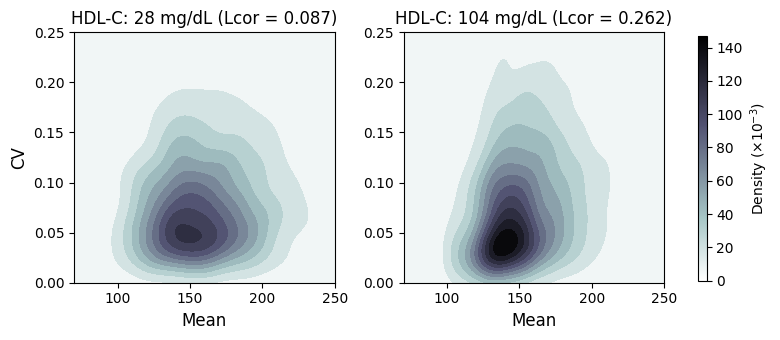

In [63]:
fig = plot_multivar_distributions(result['fits'], axes_names=['Mean', 'CV'], figsize=(7.5, 3.5),
                                all_features=result['feature_names'], heatmap=False, #vmax=5,
                                show=False, y_range=(0, 0.25), x_range=(70, 250)
                                )

axes = fig.get_axes()
for ax_idx, ax in enumerate(axes[:-1]): # Exclude colorbar axis
    # Get the current title string and extract the Lcor part
    title_str = ax.get_title()
    # Extract the Lcor value from the title
    lcor_part = title_str.split('(')[-1]  # Get the part after '('
    # Create new title with HDL-C value
    new_title = f'HDL-C: {int(Z[ax_idx, idx])} mg/dL ({lcor_part}'
    ax.set_title(new_title)
    # print(new_title)

# Adjust colorbar position vertically
cbar_ax = axes[-1]  # Last axis is the colorbar
pos = cbar_ax.get_position()
cbar_ax.set_position([pos.x0, pos.y0 + 0.034, pos.width, pos.height])  # Move up by 0.034


fig.tight_layout(rect=[0, 0, 0.93, 1])
plt.savefig('results/real/figs/ai_readi_joint_HDL.png', dpi=500, bbox_inches='tight')
fig.show()

In [65]:
idx = 1
qtile = 0.5
Z = generate_predictor(idx, qtile=qtile, minq=0.01, maxq=0.99
                       )

Z[:, 0] = 7.0  # fix HbA1c at 7.0
print(Z)

result = multivariate_frechet_regression(predictor_name, joined_df, r_squared=False, Z=Z,
                                         feature_names=aireadi_processed['feature_names'],
                                         bounds={'Mean': (40., 400), 'CV': (0., None), 'MAD': (0., None)})

[[ 7.          3.7054235  53.        ]
 [ 7.          6.19054097 53.        ]]
Performing Fréchet regression using ['HbA1c', 'log(TG)', 'HDL-C'] as predictor...
    Computing Fréchet regression of marginals...    Completed.
    Computing regression of latent correlations ...    Completed.
Completed.
    Computing regression of latent correlations ...    Completed.


C:\Users\Junyoung\AppData\Local\Temp\ipykernel_32660\2690236851.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.93, 1])
C:\Users\Junyoung\AppData\Local\Temp\ipykernel_32660\2690236851.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\Junyoung\AppData\Local\Temp\ipykernel_32660\2690236851.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


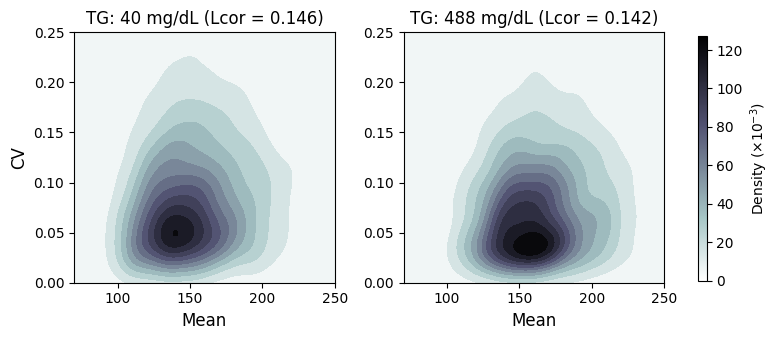

In [66]:
fig = plot_multivar_distributions(result['fits'], axes_names=['Mean', 'CV'], figsize=(7.5, 3.5),
                                all_features=result['feature_names'], heatmap=False, #vmax=5,
                                show=False, y_range=(0, 0.25), x_range=(70, 250)
                                )

axes = fig.get_axes()
for ax_idx, ax in enumerate(axes[:-1]): # Exclude colorbar axis
    # Get the current title string and extract the Lcor part
    title_str = ax.get_title()
    # Extract the Lcor value from the title
    lcor_part = title_str.split('(')[-1]  # Get the part after '('
    # Create new title with TG value
    new_title = f'TG: {int(np.exp(Z[ax_idx, idx]))} mg/dL ({lcor_part}'
    ax.set_title(new_title)
    # print(new_title)

# Adjust colorbar position vertically
cbar_ax = axes[-1]  # Last axis is the colorbar
pos = cbar_ax.get_position()
cbar_ax.set_position([pos.x0, pos.y0 + 0.034, pos.width, pos.height])  # Move up by 0.034

fig.tight_layout(rect=[0, 0, 0.93, 1])
plt.savefig('results/real/figs/ai_readi_joint_TG.png', dpi=500, bbox_inches='tight')
fig.show()